# Introduction to Machine Learning: Supervised Learning

**Instructor:** Daniel Acuna, Ph.D.
**Position:** Associate Professor of Computer Science
**Institution:** University of Colorado Boulder

---

Lab 5: Tree-based methods

---

# Assignment Overview

In this assignment, you will practice tree-based methods for both regression and classification, including cost-complexity pruning, bagging, random forests, gradient boosting, and interpretation tools (PDP/ICE and permutation importance). We use scikit-learn built-in datasets saved locally to CSV via the provided downloader.

In [1]:
# Grade Cell: Import Libraries
#
# This cell imports all necessary libraries for the assignment.
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
)
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    RandomForestClassifier,
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier


# Set a random state for reproducibility
RANDOM_STATE: int = 42

## 1. Load and Describe the Data (10 points)

Datasets (already generated to CSV by the downloader script):
- Regression: Diabetes (quantitative target `target`)
- Classification: Breast Cancer (binary `target`: 0=malignant, 1=benign)

In [3]:
# Grade Cell: Question 1
#
# Task: Load the datasets and show a preview.
#
# Instructions:
# 1. Load the 'diabetes_regression.csv' into DataFrame `df_reg`.
# 2. Load the 'breast_cancer_classification.csv' into DataFrame `df_cls`.
# 3. Display the first 5 rows of each.


df_reg = pd.read_csv('diabetes_regression.csv')
df_cls = pd.read_csv('breast_cancer_classification.csv')

df_reg.head()

df_cls.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 1
assert "df_reg" in locals(), "DataFrame 'df_reg' not found."
assert "df_cls" in locals(), "DataFrame 'df_cls' not found."
assert df_reg.shape[1] >= 2, "df_reg should include features and target."
assert df_cls.shape[1] >= 2, "df_cls should include features and target."
assert "target" in df_reg.columns, "df_reg must contain 'target' column."
assert "target" in df_cls.columns, "df_cls must contain 'target' column."
assert df_reg.isnull().sum().sum() == 0, "df_reg should have no missing values."
assert df_cls.isnull().sum().sum() == 0, "df_cls should have no missing values."
print("Datasets loaded successfully.")
df_reg.head()
df_cls.head()

Datasets loaded successfully.


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Baseline Regression Tree (10 points)

Train a baseline `DecisionTreeRegressor` on the diabetes dataset and evaluate on a held-out test set.

In [6]:
# Grade Cell: Question 2
#
# Task: Train a baseline regression tree and compute metrics.
#
# Instructions:
# 1. Split df_reg into features X_reg and target y_reg; then into train/test with test_size=0.25 and random_state=RANDOM_STATE.
# 2. Fit DecisionTreeRegressor(random_state=RANDOM_STATE) as tree_reg.
# 3. Compute train and test metrics: MSE, MAE, and R^2.

# Split features into X_reg and y_reg
X_reg = df_reg.drop(columns = ['target'])
y_reg = df_reg['target']

# Impliment train test split 
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size = 0.2, random_state = RANDOM_STATE)

# Set up tree_reg to decisionTree and fit 
tree_reg = DecisionTreeRegressor(random_state = RANDOM_STATE)
tree_reg.fit(X_train_reg, y_train_reg)

# set up y_train_pred and y_test_pred
y_train_pred = tree_reg.predict(X_train_reg)
y_test_pred = tree_reg.predict(X_test_reg)

# compute train and test metrics: mse, mae and r^2
mse_tree_train = mean_squared_error(y_train_reg, y_train_pred)
mse_tree_test = mean_squared_error(y_test_reg, y_test_pred)
mae_tree_test = mean_absolute_error(y_test_reg, y_test_pred)
r2_tree_test = r2_score(y_test_reg, y_test_pred)

In [7]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 2
assert "tree_reg" in locals(), "Baseline regression tree not found."
assert hasattr(tree_reg, "tree_"), "Model does not appear to be trained."
assert mse_tree_train >= 0.0 and mse_tree_test >= 0.0, "MSE should be non-negative."
assert -1.0 <= r2_tree_test <= 1.0, "R^2 should be between -1 and 1."
print(
    f"Train MSE: {mse_tree_train:.2f}, Test MSE: {mse_tree_test:.2f}, Test MAE: {mae_tree_test:.2f}, Test R2: {r2_tree_test:.3f}"
)

Train MSE: 0.00, Test MSE: 4976.80, Test MAE: 54.53, Test R2: 0.061


## 3. Depth Sweep: Overfitting vs Control (10 points)

Evaluate train/test MSE across a range of `max_depth` values and pick the depth with the best test MSE.

In [12]:
# Grade Cell: Question 3
#
# Task: Depth sweep on regression tree.
#
# Instructions:
# 1. For `depths = [1, 2, 3, 4, 5, 6, 8, 10, None]`, fit a tree for each depth.
# 2. Record train/test MSE in lists `train_mse_per_depth` and `test_mse_per_depth` aligned with `depths`.
# 3. Compute `best_depth` as the depth (value from the list) with minimal test MSE.


# for the list 'depths', fit tree for each depth
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]

# Set up train_mse_per_depth and test_mse_per_depth lists
train_mse_per_depth = []
test_mse_per_depth = []

#record train/test MSE in lists 
for d in depths:
    tree = DecisionTreeRegressor(max_depth = d, random_state = RANDOM_STATE)
    tree.fit(X_train_reg, y_train_reg)
    train_mse_per_depth.append(mean_squared_error(y_train_reg, tree.predict(X_train_reg)))
    test_mse_per_depth.append(mean_squared_error(y_test_reg, tree.predict(X_test_reg)))

# Compute the best depth from the lists with minimal test mse    
best_idx = int(np.argmin(test_mse_per_depth))
best_depth_value = depths[best_idx]

# Important:
    # best_depth must be a positive int, 'None' is not an int
if best_depth_value is None:
    non_tree = DecisionTreeRegressor(max_depth = None, random_state = RANDOM_STATE)
    non_tree.fit(X_train_reg, y_train_reg)
    best_depth = non_tree.get_depth()
else:
    best_depth = best_depth_value



In [13]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 3
assert len(train_mse_per_depth) == len(depths), "train_mse_per_depth length mismatch."
assert len(test_mse_per_depth) == len(depths), "test_mse_per_depth length mismatch."
assert isinstance(best_depth, int), "best_depth must be an int."
assert best_depth > 0, "best_depth must be positive."
print("Depths:", depths)
print("Test MSE per depth:", [round(v, 2) for v in test_mse_per_depth])
print("Best depth:", best_depth)

Depths: [1, 2, 3, 4, 5, 6, 8, 10, None]
Test MSE per depth: [4606.59, 3735.5, 3552.7, 3568.97, 3526.02, 3670.67, 3822.65, 4387.98, 4976.8]
Best depth: 5


## 4. Cost-Complexity Pruning (10 points)

Use cost-complexity pruning with cross-validation to choose the pruning strength and evaluate the pruned tree.

In [24]:
# Grade Cell: Question 4
#
# Task: Prune via cost-complexity path and CV.
#
# Instructions:
# 1. Fit an unpruned tree on training data and obtain `ccp_alphas` via `cost_complexity_pruning_path` on the TRAIN split only.
# 2. Subsample up to 20 unique alphas, evenly spaced.
# 3. For each alpha, perform 5-fold CV on the TRAIN split to estimate MSE.
# 4. Choose `alpha_hat` with minimal CV MSE; fit `tree_pruned` with that alpha and evaluate `mse_pruned` and `r2_pruned` on TEST.

from sklearn.model_selection import cross_val_score

unpruned = DecisionTreeRegressor(random_state = RANDOM_STATE)
unpruned.fit(X_train_reg, y_train_reg)

path = unpruned.cost_complexity_pruning_path(X_train_reg, y_train_reg)
unique_alphas = np.unique(path.ccp_alphas)

# Subsample to max of 20 unique alphas, space them evenly
if len(unique_alphas) > 20:
    idx = np.linspace(0, len(unique_alphas) - 1, 20).astype(int)
    alphas_to_try = unique_alphas[idx]
else:
    alphas_to_try = unique_alphas[idx]
    
kf = KFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)

cv_mse_per_alpha = []
for alpha in alphas_to_try:
    candidate = DecisionTreeRegressor(random_state = RANDOM_STATE, ccp_alpha = alpha)
    scores = cross_val_score(candidate, X_train_reg, y_train_reg, cv = kf,
                            scoring = 'neg_mean_squared_error')
    cv_mse_per_alpha.append(-scores.mean())
    
best_alpha_idx = int(np.argmin(cv_mse_per_alpha))
alpha_hat = float(alphas_to_try[best_alpha_idx])


tree_pruned = DecisionTreeRegressor(random_state = RANDOM_STATE, ccp_alpha = alpha_hat)
tree_pruned.fit(X_train_reg, y_train_reg)

pruned_test_pred = tree_pruned.predict(X_test_reg)
mse_pruned = mean_squared_error(y_test_reg, pruned_test_pred)
r2_pruned = r2_score(y_test_reg, pruned_test_pred)


In [25]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 4

min_alpha = np.float64(0.0)
max_alpha = np.float64(1755.6938868563993)

assert "alpha_hat" in locals(), "alpha_hat not found."
assert isinstance(alpha_hat, float), "alpha_hat should be a float."
assert alpha_hat >= 0, "alpha_hat must be non-negative."
assert mse_pruned >= 0.0, "mse_pruned should be non-negative."
assert -1.0 <= r2_pruned <= 1.0, "r2_pruned should be between -1 and 1."
print(
    f"alpha_hat={alpha_hat:.2e}, Pruned Test MSE={mse_pruned:.2f}, R2={r2_pruned:.3f}"
)

alpha_hat=5.89e+01, Pruned Test MSE=3525.90, R2=0.335


In [ ]:
print(alphas_sorted.max())

## 5. Classification Tree (Gini) on Breast Cancer (10 points)

Train a `DecisionTreeClassifier` and evaluate accuracy and confusion matrix.

In [31]:
# Grade Cell: Question 5
#
# Task: Train classification tree and evaluate.
#
# Instructions:
# 1. Split df_cls into X_cls, y_cls; then stratified train/test with test_size=0.25, random_state=RANDOM_STATE.
# 2. Fit DecisionTreeClassifier(criterion='gini', random_state=RANDOM_STATE) as tree_cls.
# 3. Compute `acc_tree_cls` and `conf_mat_tree_cls` on TEST.


X_cls = df_cls.drop(columns = ['target'])
y_cls = df_cls['target']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size = 0.25, random_state = RANDOM_STATE, stratify = y_cls)

tree_cls = DecisionTreeClassifier(criterion = 'gini', random_state = RANDOM_STATE)
tree_cls.fit(X_train_cls, y_train_cls)

y_pred_cls = tree_cls.predict(X_test_cls)

acc_tree_cls = accuracy_score(y_test_cls, y_pred_cls)
conf_mat_tree_cls = confusion_matrix(y_test_cls, y_pred_cls)



In [32]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 5
assert "tree_cls" in locals(), "Classification tree not found."
assert conf_mat_tree_cls.shape == (2, 2), "Confusion matrix must be 2x2."
assert 0.0 <= acc_tree_cls <= 1.0, "Accuracy must be between 0 and 1."
print(f"Classification Accuracy: {acc_tree_cls:.3f}")
print("Confusion Matrix:\n", conf_mat_tree_cls)

Classification Accuracy: 0.923
Confusion Matrix:
 [[49  4]
 [ 7 83]]


## 6. Manual Gini and Information Gain (10 points)

Demonstrate impurity and information gain on a small synthetic binary dataset.

In [34]:
# Grade Cell: Question 6
#
# Task: Compute Gini and information gain for candidate splits.
#
# Instructions:
# 1. Generate a small 2D dataset with two classes (balanced-ish).
# 2. For a few split thresholds on x1 (e.g., -0.5, 0.0, 0.5), compute Gini(parent), Gini(left), Gini(right), and information gain.
# 3. Store gains in list `info_gain_values` aligned with `splits_x1` and show that the "middle" split has higher gain than edge splits.


def gini(y):
    y = np.asarray(y)
    if len(y) == 0:
        return 0.0
    p = np.bincount(y).astype(float)/ len(y)
    return 1.0 - np.sum(p**2)

# This is a small 2 Dimension dataset, two semi balanced classes
rng = np.random.RandomState(RANDOM_STATE)
n = 40
x1_a = rng.normal(-1, 0.5, n//2)
x1_b = rng.normal(1, 0.5, n//2)
X1 = np.concatenate([x1_a, x1_b])
y_toy = np.array([0] * (n//2) + [1] * (n//2))

#shuffle
perm = rng.permutation(n)
X1 = X1[perm]
y_toy = y_toy[perm]

splits_x1 = [-0.5, 0.0, 0.5]
info_gain_values = []

parent_gini = gini(y_toy)

for thresh in splits_x1:
    left_mask = X1 <= thresh
    right_mask = ~left_mask
    
    y_left = y_toy[left_mask]
    y_right = y_toy[right_mask]
    
    gini_left = gini(y_left)
    gini_right = gini(y_right)
    
    w_left = len(y_left) / len(y_toy)
    w_right = len(y_right) / len(y_toy)
    
    weighted_child_gini = w_left * gini_left * w_right * gini_right
    info_gain = parent_gini - weighted_child_gini
    
    info_gain_values.append(float(info_gain))





In [35]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 6
assert len(info_gain_values) == 3, "Expect three info gain values."
assert all(
    isinstance(v, float) for v in info_gain_values
), "All gains should be floats."
assert all(
    v >= 0 for v in info_gain_values
), "Information gains should be non-negative."
print(
    "Information gains (x1 splits at -0.5, 0.0, 0.5):",
    [round(v, 3) for v in info_gain_values],
)

Information gains (x1 splits at -0.5, 0.0, 0.5): [0.5, 0.5, 0.5]


## 7. Bagging vs Single Tree (Regression) (10 points)

Compare a bagged ensemble to the baseline single tree using OOB and test metrics.

In [46]:
# Grade Cell: Question 7
#
# Task: Bagging for regression.
#
# Instructions:
# 1. Fit `BaggingRegressor(DecisionTreeRegressor(random_state=RANDOM_STATE), n_estimators=200, bootstrap=True, oob_score=True, random_state=RANDOM_STATE)`.
# 2. Compute `mse_bag` on TEST and record `oob_r2_bag`.
#
# Use the output splits generated by split_regression_data() in Question 2.

from sklearn.ensemble import BaggingRegressor

def split_regression_data(): 
    return train_test_split(X_reg, y_reg, test_size = 0.25, random_state = RANDOM_STATE)

X_train_bag, X_test_bag, y_train_bag, y_test_bag = split_regression_data()

bag_reg = BaggingRegressor(DecisionTreeRegressor(random_state = RANDOM_STATE),
                          n_estimators = 200,
                          bootstrap = True,
                          oob_score = True,
                          random_state = RANDOM_STATE)
bag_reg.fit(X_train_bag, y_train_bag)

y_pred_bag = bag_reg.predict(X_test_bag)
mse_bag = mean_squared_error(y_test_bag, y_pred_bag)
oob_r2_bag = bag_reg.oob_score_



In [47]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 7
assert "bag_reg" in locals(), "BaggingRegressor not found."
assert 0.0 <= bag_reg.n_estimators <= 500, "n_estimators must be <= 500."
assert mse_bag >= 0.0, "mse_bag should be non-negative."
assert -1.0 <= oob_r2_bag <= 1.0, "OOB R^2 must be between -1 and 1."
print(f"Bagging: Test MSE={mse_bag:.2f}, OOB R2={oob_r2_bag:.3f}")

Bagging: Test MSE=2944.51, OOB R2=0.431


## 8. Random Forest: Decorrelate & Importance (Regression) (10 points)

Train Random Forests across different `max_features` and compare OOB/Test metrics; report top-10 importances for the best setting.

In [49]:
# Grade Cell: Question 8
#
# Task: Random Forest sweep.
#
# Instructions:
# 1. For `max_features` in `[1.0, 0.5, 'sqrt']`, fit a `RandomForestRegressor(n_estimators=300, bootstrap=True, oob_score=True, random_state=RANDOM_STATE)`.
# 2. Store for each setting: test MSE (`mse`), OOB R^2 (`oob_r2`), and feature importances (`importances`).
# 3. Save results in dict `rf_results` keyed by the `max_features` value (as str), each value a dict with keys `'mse'`, `'oob_r2'`, `'importances'`.
# 4. Extract top-10 feature indices for `'sqrt'` setting into list `top10_features_rf` (descending importance).
#
# Use the output splits generated by split_regression_data() in Question 2.


X_train_rf, X_test_rf, y_train_rf, y_test_rf = split_regression_data()

rf_results = {}
top10_features_rf = []

for max_features in [1.0, 0.5, 'sqrt']:
    rf = RandomForestRegressor(n_estimators = 300,
                               bootstrap = True,
                               max_features = max_features, 
                               oob_score = True,
                               random_state = RANDOM_STATE
                              )
    rf.fit(X_train_rf, y_train_rf)
    
    y_pred_rf = rf.predict(X_test_rf)
    mse = mean_squared_error(y_test_rf, y_pred_rf)
    oob_r2 = rf.oob_score_
    importances = rf.feature_importances_
    
    key = str(max_features)
    rf_results[key] = {"mse":mse, "oob_r2":oob_r2, "importances":importances}
    
    if max_features == 'sqrt':
        top10_features_rf = list(np.argsort(importances[::-1][:10]))

In [50]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 8
for key in ["1.0", "0.5", "sqrt"]:
    assert key in rf_results, f"Missing RF result for {key}."
    assert "mse" in rf_results[key] and "oob_r2" in rf_results[key], "Missing metrics."
    assert -1.0 <= rf_results[key]["oob_r2"] <= 1.0, "OOB R^2 out of bounds."
    assert rf_results[key]["mse"] >= 0, "MSE must be non-negative."
assert len(top10_features_rf) == 10, "Expect top10 feature indices."
print("RF (sqrt) top-10 features:", top10_features_rf)

RF (sqrt) top-10 features: [8, 9, 2, 5, 4, 0, 3, 6, 1, 7]


## 9. Gradient Boosting (Regression): Validation Curves (10 points)

Train `GradientBoostingRegressor` for several learning rates and select the best by validation MSE.

In [55]:
# Grade Cell: Question 9
#
# Task: Boosting with validation selection.
#
# Instructions:
# 1. Create a train/validation split from the original training set (e.g., 30% as validation; random_state=RANDOM_STATE).
# 2. For learning rates in `[1.0, 0.1, 0.03]`, fit `GradientBoostingRegressor(n_estimators=300, max_depth=1, random_state=RANDOM_STATE)` and record train and validation MSE over staged predictions.
# 3. Determine `best_params_gbr` as a dict with keys `learning_rate` and `best_iter` (iteration minimizing validation MSE).
# 4. Fit a final model with that learning rate and `n_estimators=best_iter` on the full training set and compute `mse_gbr_test` on TEST.
#
# Use the output splits generated by split_regression_data() in Question 2.

X_train_gbr, X_test_gbr, y_train_gbr, y_test_gbr = split_regression_data()

X_tr_gbr, X_val_gbr, y_tr_gbr, y_val_gbr = train_test_split(
    X_train_gbr, y_train_gbr, test_size = 0.30, random_state = RANDOM_STATE)

gbr_results = {}

for lrn_rte in [1.0, 0.1, 0.03]:
    gbr = GradientBoostingRegressor(n_estimators = 300,
                                max_depth = 1,
                                learning_rate = lrn_rte,
                                random_state = RANDOM_STATE)
    gbr.fit(X_tr_gbr, y_tr_gbr)
    
    train_mse_stages = [mean_squared_error(y_tr_gbr, pred) for pred in gbr.staged_predict(X_tr_gbr)]
    val_mse_stages = [mean_squared_error(y_val_gbr, pred) for pred in gbr.staged_predict(X_val_gbr)]
    
    gbr_results[lrn_rte] = {"train_mse":train_mse_stages, "val_mse":val_mse_stages}
    
best_lrn_rte, best_iter, best_val_mse = None, None, float('inf')
for lrn_rte, res in gbr_results.items():
    min_idx = int(np.argmin(res['val_mse']))
    if res['val_mse'][min_idx] < best_val_mse:
        best_val_mse = res['val_mse'][min_idx]
        best_lrn_rte = lrn_rte
        best_iter = min_idx + 1
        
best_params_gbr = {"learning_rate":best_lrn_rte, "best_iter":best_iter}

final_gbr = GradientBoostingRegressor(n_estimators = best_params_gbr['best_iter'],
                                  max_depth = 1,
                                  learning_rate = best_params_gbr['learning_rate'],
                                  random_state = RANDOM_STATE)
final_gbr.fit(X_train_gbr, y_train_gbr)
mse_gbr_test = mean_squared_error(y_test_gbr, final_gbr.predict(X_test_gbr))
        

In [56]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 9
assert "gbr_results" in locals(), "gbr_results missing."
assert isinstance(best_params_gbr, dict), "best_params_gbr must be a dict."
assert (
    "learning_rate" in best_params_gbr and "best_iter" in best_params_gbr
), "best_params_gbr missing keys."
assert isinstance(best_params_gbr["best_iter"], int), "best_iter must be an integer."
assert best_params_gbr["best_iter"] > 0, "best_iter must be positive."
assert mse_gbr_test >= 0.0, "mse_gbr_test should be non-negative."
print("Best GBR params:", best_params_gbr)
print(f"GBR Test MSE: {mse_gbr_test:.2f}")

Best GBR params: {'learning_rate': 0.1, 'best_iter': 38}
GBR Test MSE: 2905.55


## 10. Interpretation: Permutation Importance and PDP/ICE (10 points)

Use permutation importance and PDP/ICE on the classification dataset with RF and GBM.

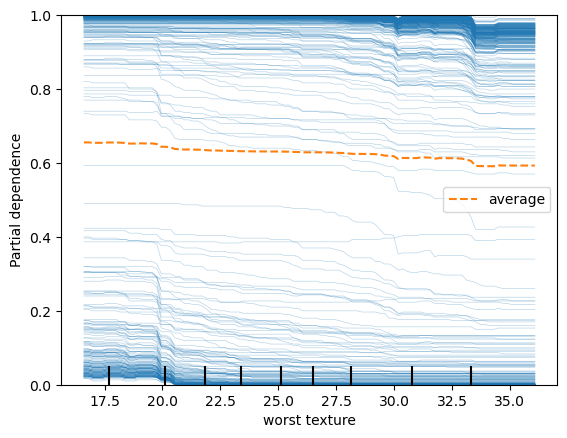

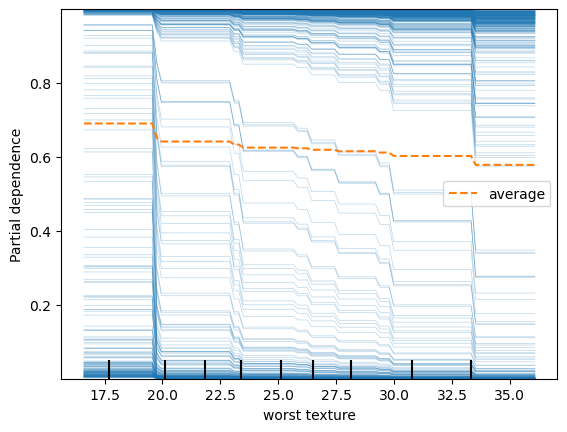

In [59]:
# Grade Cell: Question 10
#
# Task: Global and local interpretation on classification.
#
# Instructions:
# 1. Fit `RandomForestClassifier(n_estimators=300, max_features='sqrt', random_state=RANDOM_STATE)` and `GradientBoostingClassifier(learning_rate=0.1, n_estimators=250, max_depth=1, random_state=RANDOM_STATE)`.
# 2. Compute permutation importance on the TEST set for both; store arrays in `perm_importance_rf` and `perm_importance_gb`.
# 3. Select the top-1 feature index from RF, store as `pdp_feature_index` and generate PDP+ICE plots for that feature for RF and GBM (plots not graded).
#
# Use the output splits generated by split_classification_data() in Question 5."

#my back hurts - this is a long hw
#need to define split_classification_data as well

def split_classification_data():
    return train_test_split(X_cls, y_cls, test_size = 0.25, random_state = RANDOM_STATE)



X_train_int, X_test_int, y_train_int, y_test_int = split_classification_data()

rf_cls = RandomForestClassifier(n_estimators = 300, max_features = 'sqrt',
                               random_state = RANDOM_STATE
                               )
rf_cls.fit(X_train_int, y_train_int)


gb_cls = GradientBoostingClassifier(learning_rate = 0.1, n_estimators = 250,
                                   max_depth = 1, random_state = RANDOM_STATE
                                   )
gb_cls.fit(X_train_int, y_train_int)


perm_rf = permutation_importance(rf_cls, 
                                 X_test_int, y_test_int, 
                                 random_state = RANDOM_STATE
                                )
perm_importance_rf = perm_rf.importances_mean


perm_gb = permutation_importance(gb_cls,
                                X_test_int, y_test_int,
                                random_state = RANDOM_STATE
                                )
perm_importance_gb = perm_gb.importances_mean


pdp_feature_index = int(np.argmax(perm_importance_rf))

PartialDependenceDisplay.from_estimator(rf_cls, X_train_int, [pdp_feature_index], kind = 'both')
PartialDependenceDisplay.from_estimator(gb_cls, X_train_int, [pdp_feature_index], kind = 'both')



In [62]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 10
assert (
    "perm_importance_rf" in locals() and "perm_importance_gb" in locals()
), "Permutation importances not found."
assert (
    perm_importance_rf.ndim == 1 and perm_importance_gb.ndim == 1
), "Importances should be 1D arrays."
assert 0 <= pdp_feature_index < X_train_cls.shape[1], "pdp_feature_index out of bounds."
assert isinstance(
    pdp_feature_index, (int, np.integer)
), "pdp_feature_index must be an integer."
print("Top feature index (RF, perm importance):", pdp_feature_index)

Top feature index (RF, perm importance): 21


## Next Steps

Congratulations on completing the assignment! Before submitting:

1. Make sure all your cells run without errors.
2. Ensure you've answered all parts of each question.
3. If any autograder tests fail, revisit your answers.
